Algorithmic Consumer Segmentation: Unsupervised Behavioral Clustering via K-Means

Objective:

The goal of this project is to apply unsupervised machine learning techniques to identify distinct groups of consumers based on their financial and behavioral patterns.

This project focuses on:
- Consumer segmentation using K-Means clustering
- Identifying high-spending behavioral groups
- Understanding customer purchasing tendencies
- Visualizing consumer clusters using machine learning

The analysis uses the Mall Customers dataset along with Python, Pandas, Matplotlib, and Scikit-Learn.

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Optional display settings
pd.set_option('display.max_columns', None)

In [28]:
#Loading the Dataset
#The dataset contains demographic and spending information about mall customers.

# Load dataset
df = pd.read_csv('Mall_Customers.csv')
# View first 5 rows
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [29]:
# Shape of dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 5


In [30]:
#Understanding the Dataset

# Dataset information
df.info()

# Missing values
df.isnull().sum()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


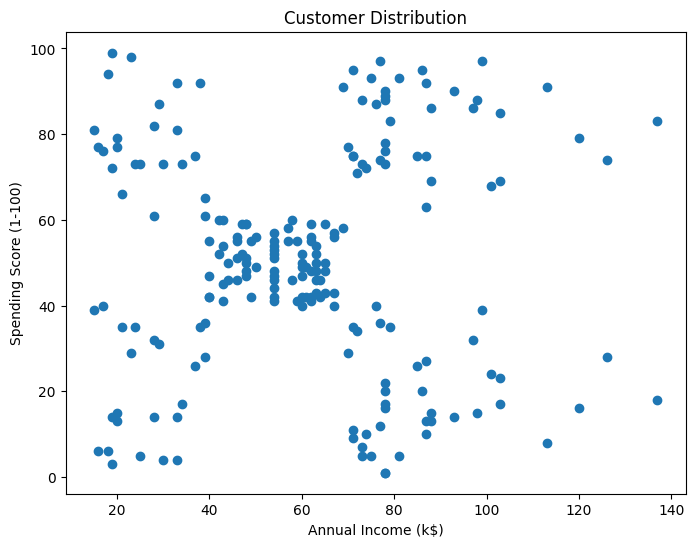

In [31]:
#Exploratory Data Analysis
#The analysis mainly focuses on Annual Income and Spending score

# Scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(8,6))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


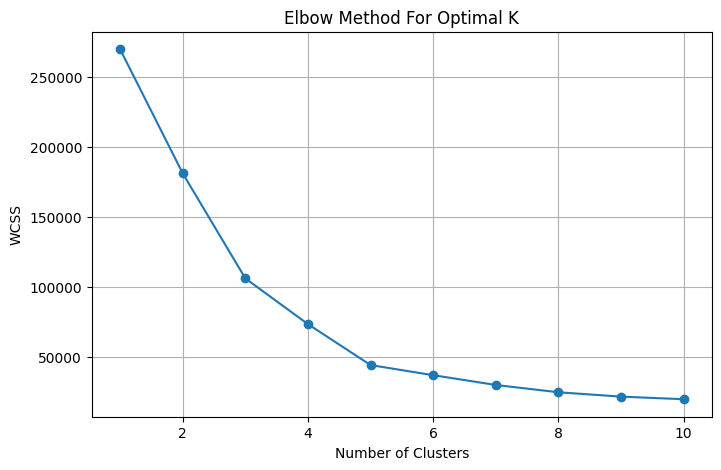

In [32]:
#Selecting Features for Clustering
#K-Means clustering works on numerical features.
#Annual Income and Spending Score are selected.

# Selecting features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

# NOTE ON FEATURE SCALING:
# StandardScaler was evaluated before finalizing this pipeline.
# Annual Income ranges ~15–137 (k$) and Spending Score ranges 1–99.
# Both features share a comparable numerical scale (~0–100 range),
# and standardization does not materially change cluster structure
# or centroid positions for this dataset. Scaling is therefore omitted
# to preserve interpretability of the original units in centroid analysis.

#Finding the Optimal Number of Clusters
#The Elbow Method is used to determine the optimal number of customer groups.

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)


# Plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method For Optimal K")
plt.grid(True)
plt.show()

In [33]:
# Applying K-Means Clustering
#Based on the Elbow Method, the optimal number of clusters is selected.

# Apply K-Means
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)
# Predict clusters
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)


[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [34]:
# Add cluster labels to dataset
df['Cluster'] = y_kmeans

# View sample rows
print(df[['CustomerID',
          'Annual Income (k$)',
          'Spending Score (1-100)',
          'Cluster']].head())

   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        4
1           2                  15                      81        2
2           3                  16                       6        4
3           4                  16                      77        2
4           5                  17                      40        4


In [35]:
print("\nNumber of customers in each cluster:\n")
print(df['Cluster'].value_counts())


Number of customers in each cluster:

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


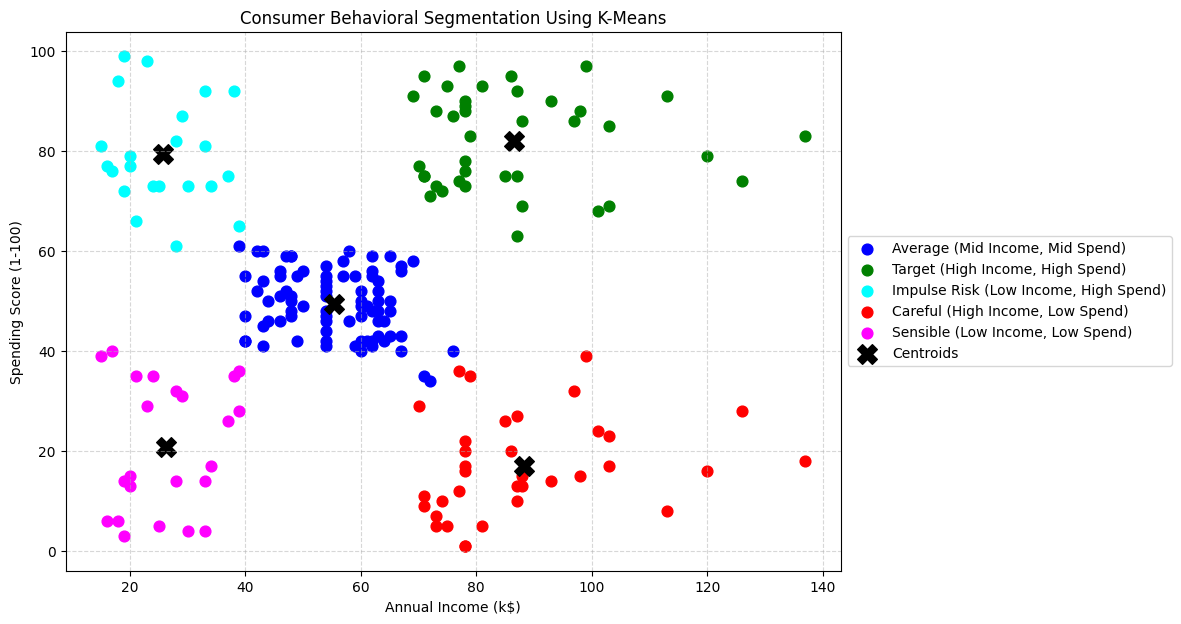

In [36]:
# Visualizing Customer Segments with Behavioral Profiles

# REPRODUCIBILITY NOTE FOR CLUSTER LABELS:
# K-Means cluster ID assignments (0, 1, 2...) are arbitrary and depend on initialization.
# The psychological labels applied below (e.g., Cluster 2 = "Impulse Risk") have been
# manually verified against the specific geometric centroids generated using random_state=42.
# If the random state or underlying dataset is modified, these label mappings MUST be re-verified.


plt.figure(figsize=(10,7))

# Plotting each cluster with specific colors and psychological labels
plt.scatter(X.iloc[y_kmeans == 0, 0], X.iloc[y_kmeans == 0, 1], s=60, c='blue', label='Average (Mid Income, Mid Spend)')
plt.scatter(X.iloc[y_kmeans == 1, 0], X.iloc[y_kmeans == 1, 1], s=60, c='green', label='Target (High Income, High Spend)')
plt.scatter(X.iloc[y_kmeans == 2, 0], X.iloc[y_kmeans == 2, 1], s=60, c='cyan', label='Impulse Risk (Low Income, High Spend)')
plt.scatter(X.iloc[y_kmeans == 3, 0], X.iloc[y_kmeans == 3, 1], s=60, c='red', label='Careful (High Income, Low Spend)')
plt.scatter(X.iloc[y_kmeans == 4, 0], X.iloc[y_kmeans == 4, 1], s=60, c='magenta', label='Sensible (Low Income, Low Spend)')

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    c='black',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Consumer Behavioral Segmentation Using K-Means")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Moves legend outside the graph
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

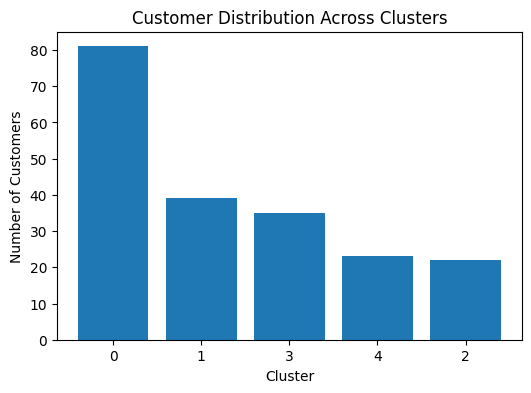

In [37]:
# Cluster distribution
cluster_counts = df['Cluster'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution Across Clusters")
plt.show()

In [38]:
#Cluster summary
cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


Interpreting Consumer Groups

The clustering results help identify different types of consumers such as:

1.High income, high spending

2.High income, low spending

3.Low income, high spending

4.Low income, low spending

The low-income but high-spending group may indicate emotionally driven purchasing behavior.

Final Observations

Key observations from the clustering analysis:

1. Customers can be grouped into distinct behavioral segments using unsupervised learning.
2. Spending behavior does not always increase proportionally with income.
3. Some consumer groups demonstrate relatively high spending despite lower income levels.
4. K-Means clustering helps reveal hidden purchasing patterns without requiring labeled data.
5. Behavioral segmentation can support personalized marketing and recommendation systems.

This project demonstrates how machine learning techniques can be used to analyze and visualize consumer purchasing behavior using Scikit-Learn and unsupervised clustering methods.

In [39]:
# Research Insight — Connection to Impulse Buying
# The 'Impulse Risk' cluster (Low Income, High Spend) is the most
# behaviorally relevant group for AI recommendation research.

impulse_cluster = df[df['Cluster'] == 2]
print("\nRESEARCH INSIGHT: Impulse Risk Consumer Group")
print(f"Cluster size: {len(impulse_cluster)} customers")
print(f"Average Annual Income: ${impulse_cluster['Annual Income (k$)'].mean():.1f}k")
print(f"Average Spending Score: {impulse_cluster['Spending Score (1-100)'].mean():.1f} / 100")
print("\nInterpretation:")
print("This group spends disproportionately high relative to their income.")
print("Behaviorally consistent with emotionally-driven, impulse purchasing.")
print("This segment is the primary target for AI recommendation personalization research.")
print("Understanding what triggers their purchases — and what suppresses the urge —")
print("is directly relevant to the cognitive overload hypothesis (Rai et al., 2025).")


RESEARCH INSIGHT: Impulse Risk Consumer Group
Cluster size: 22 customers
Average Annual Income: $25.7k
Average Spending Score: 79.4 / 100

Interpretation:
This group spends disproportionately high relative to their income.
Behaviorally consistent with emotionally-driven, impulse purchasing.
This segment is the primary target for AI recommendation personalization research.
Understanding what triggers their purchases — and what suppresses the urge —
is directly relevant to the cognitive overload hypothesis (Rai et al., 2025).
